## Imports

In [72]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler

# Part A — Profiling, cleaning, and the data story

## Loading and Data Profiling

In [2]:
try:
    raw_titanic_data=sns.load_dataset("titanic")
    print(raw_titanic_data.head())
except:
    raw_titanic_data=pd.read_csv("input_data/titanic.csv")

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
print("raw_titanic_data.info")
print("-" * len("raw_titanic_data.info"))
raw_titanic_data.info()
print("*"*100)
print("raw_titanic_data.describe\n",
         "-"*len("raw_titanic_data.describe"),"\n",
           raw_titanic_data.describe())
print("*"*100)
print("raw_titanic_data.shape\n", "-"*len("raw_titanic_data.shape"),"\n", raw_titanic_data.shape)


raw_titanic_data.info
---------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
***********************************

## Missing Data Identification and Handling

In [4]:
missing_data = pd.DataFrame({
    "Missing Count": raw_titanic_data.isna().sum(),
    "Missing %": raw_titanic_data.isna().mean() * 100
})

print(missing_data)

             Missing Count  Missing %
survived                 0   0.000000
pclass                   0   0.000000
sex                      0   0.000000
age                    177  19.865320
sibsp                    0   0.000000
parch                    0   0.000000
fare                     0   0.000000
embarked                 2   0.224467
class                    0   0.000000
who                      0   0.000000
adult_male               0   0.000000
deck                   688  77.216611
embark_town              2   0.224467
alive                    0   0.000000
alone                    0   0.000000


4 columns only have missing values - age, embarked, deck, embark_town

### Decisions taken for those columns: 

age --> ~20% --> IMPUTE

embarked --> ~0.2% --> DROP ROWS

deck --> ~78% --> DROP COLUMN

embark_town --> ~0.2% --> DROP ROWS

### Justification for those decisions
As per project guidelines, under 5% are missing, rows must be dropped and if missing values are between 5%–30% missing, values can be imputed. So, rows where embarked and embarked_rows are missing, rows are dropped. Where age is missing, values will be imputed.

For columns where missing rate is so high that imputation is not possible, coulumn can be dropped or encoded missing value.
Since, missing values of deck column donot effect the evaluations being made in this project, the column is being dropped.

In [ ]:
missing_handled_df=raw_titanic_data.copy()
print("init cols: ",missing_handled_df.shape)

## drop column deck
missing_handled_df.drop(columns=['deck'], inplace=True)
print("after dropping 1 col",missing_handled_df.shape)

## drop embarked = na rows
missing_handled_df = missing_handled_df.dropna(subset=["embarked"])
print("after dropping rows where embarked is NA",missing_handled_df.shape)

## drop embark_town = na rows
missing_handled_df = missing_handled_df.dropna(subset=["embark_town"])
print("after dropping rows where embarked is NA",missing_handled_df.shape)

## impute age values with median of corresponding passenger class
missing_handled_df["age"] = missing_handled_df["age"].fillna(missing_handled_df.groupby("pclass")["age"].transform("median"))

init cols:  (891, 15)
after dropping 1 col (891, 14)
after dropping rows where embarked is NA (889, 14)
after dropping rows where embarked is NA (889, 14)


## Univariate Analysis

### histogram - age

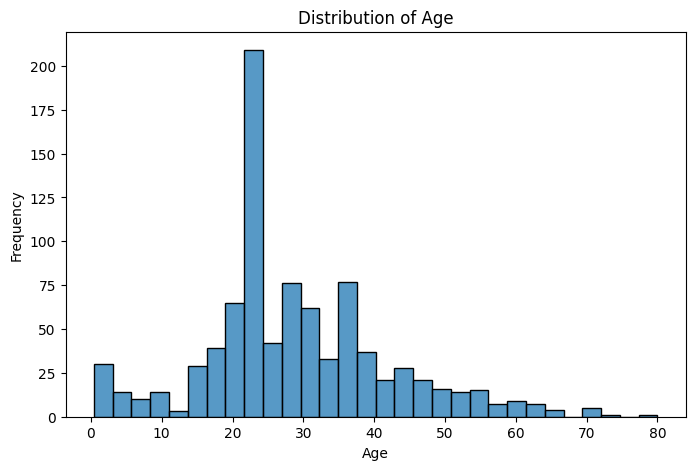

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=missing_handled_df, x="age", bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### histigram - fare

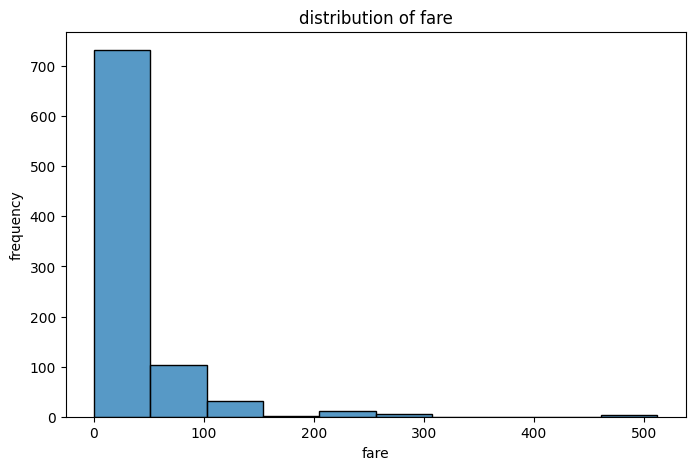

In [16]:
plt. figure(figsize=(8,5))
sns.histplot(data=missing_handled_df, x="fare", bins=10)
plt.title("distribution of fare")
plt.xlabel("fare")
plt.ylabel("frequency")
plt.show()

### box plot - age

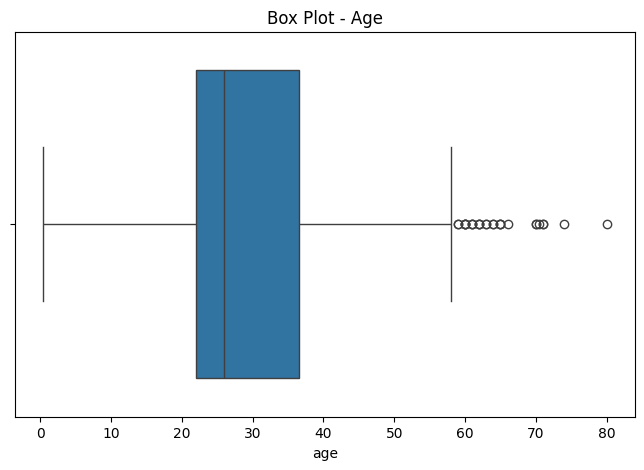

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=missing_handled_df, x="age")
plt.title("Box Plot - Age")
plt.xlabel("age")
plt.show()

### box plot - fare

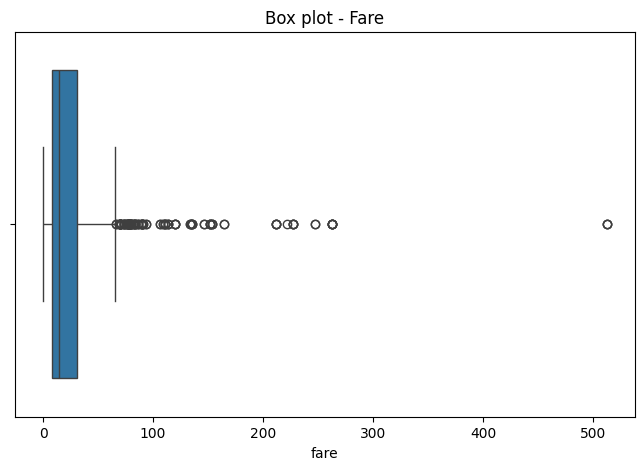

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=missing_handled_df, x="fare")
plt.title("Box plot - Fare")
plt.xlabel("fare")
plt.show()

### report outliers 

In [23]:
def calculate_outliers(df, column_name):
    q1=df[column_name].quantile(0.25)
    q3=df[column_name].quantile(0.75)

    lower_limit=q1-(1.5*q3)
    upper_limit=q3+(1.5*q1)

    iqr=q3-q1

    outliers=df[
                (df[column_name]<lower_limit) | (df[column_name]>upper_limit)
                ]
    return {"lower_limit":lower_limit,
            "upper_limit": upper_limit,
            "q1":q1,
            "q3":q3,
            "iqr":iqr,
            "outliers": outliers,
            "count_of_outliers": len(outliers)
            }

In [27]:
print("count of age outliers", calculate_outliers(missing_handled_df, "age")["count_of_outliers"])
print("*"*30)
print("count of fare outliers", calculate_outliers(missing_handled_df, "fare")["count_of_outliers"])


count of age outliers 7
******************************
count of fare outliers 169


### skewness (deteremined using fare)

In [31]:
mean_fare=missing_handled_df["fare"].mean()
median_fare=missing_handled_df["fare"].median()
mode_fare=missing_handled_df["fare"].mode()[0]

print("mean fare", mean_fare)
print("median fare", median_fare)
print("mode fare", mode_fare)

if mean_fare < median_fare and median_fare < mode_fare:
    print("left skewed")
elif mode_fare < median_fare and median_fare < mean_fare:
    print("right skewed")

mean fare 32.09668087739032
median fare 14.4542
mode fare 8.05
right skewed


#### To which side is the distribution skewed and why?
The values of mean, median and mode of fare are 32.09, 14.45, 8.05 respectively.
This means, mean < median < mode.
Hence, this distribution of fare is RIGHT SKEWED

## Bivariate Analysis

### Survival rate

Survival rate broken down by sex, pclass, both sex and pclass are displayed by the dictionaries - sex_wise_survival_rate, pclass_wise_survival_rate and sex_pclass_wise_survival_rate respectively


In [35]:
sex_values=missing_handled_df["sex"].unique()
# print(sex_values)
pclass_values=missing_handled_df["pclass"].unique()

sex_wise_survival_rate={}
pclass_wise_survival_rate={}
sex_pclass_wise_survival_rate={}


for sex in sex_values:
    mask_sex=missing_handled_df["sex"]==sex
    sex_wise_survival_rate[sex] = missing_handled_df.loc[mask_sex, "survived"].mean()*100
    

    for pclass in pclass_values:
        mask_pclass=missing_handled_df["pclass"]==pclass
        pclass_wise_survival_rate[pclass] = missing_handled_df.loc[mask_pclass, "survived"].mean()*100

        mask_sex_pclass=(
                (missing_handled_df["pclass"]==pclass)
                & (missing_handled_df["sex"]==sex)
                )
        sex_pclass_wise_survival_rate[str(sex)+"_"+str(pclass)] = missing_handled_df.loc[mask_sex_pclass, "survived"].mean()*100

print(sex_wise_survival_rate)
print(pclass_wise_survival_rate)
print(sex_pclass_wise_survival_rate)

{'male': np.float64(18.890814558058924), 'female': np.float64(74.03846153846155)}
{np.int64(3): np.float64(24.236252545824847), np.int64(1): np.float64(62.616822429906534), np.int64(2): np.float64(47.28260869565217)}
{'male_3': np.float64(13.544668587896252), 'male_1': np.float64(36.885245901639344), 'male_2': np.float64(15.74074074074074), 'female_3': np.float64(50.0), 'female_1': np.float64(96.73913043478261), 'female_2': np.float64(92.10526315789474)}


### Correlation Matrix

In [37]:
correlation_matrix=missing_handled_df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].corr()
print(correlation_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.052051 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.405549  0.081656  0.016824 -0.548193
age      -0.052051 -0.405549  1.000000 -0.242807 -0.170089  0.120938
sibsp    -0.034040  0.081656 -0.242807  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.170089  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.120938  0.160887  0.217532  1.000000


### Heat map

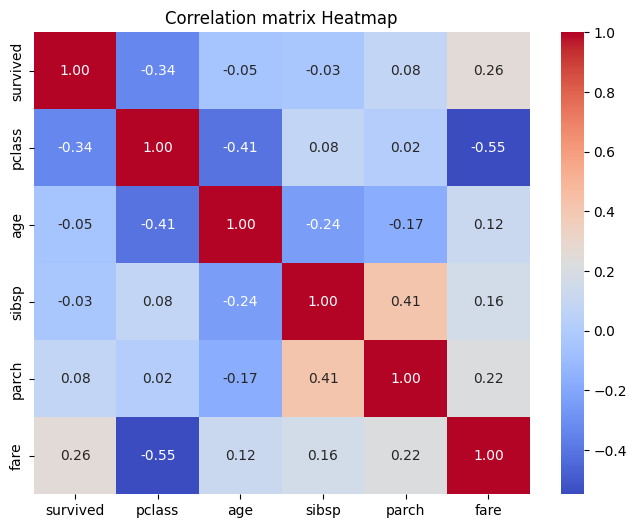

In [40]:
plt.figure(figsize=(8,6))
sns.heatmap(data=correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix Heatmap")
plt.show()

In [61]:
correlation_stack_pairs = correlation_matrix.where(
        np.triu(
        np.ones(correlation_matrix.shape)
        ,k=1
            ).astype(bool)
    ).stack()

top2values=correlation_stack_pairs.reindex(
    correlation_stack_pairs.abs().sort_values(ascending=False).index
).head(2)
print(top2values)

pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64


## Multivariate Analysis - Data Story

#### (Plot 1) Bar Plot  - Survival Rate by Sex

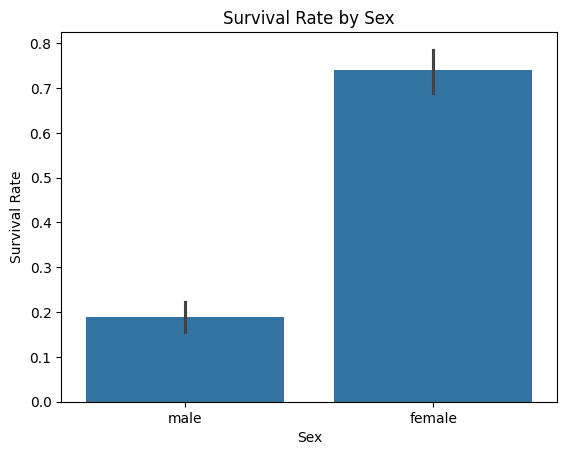

In [66]:
# missing_handled_df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].head()
plt.Figure(figsize=(2,2))
sns.barplot(
    data=missing_handled_df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Sex")
plt.show()

Survival rate  significantly varies by gender. Survival rate is much higher for females. It is around 75% in females and 19-20% in males.

#### (Plot 2) Bar Plot - Survival Rate By Passenger Class

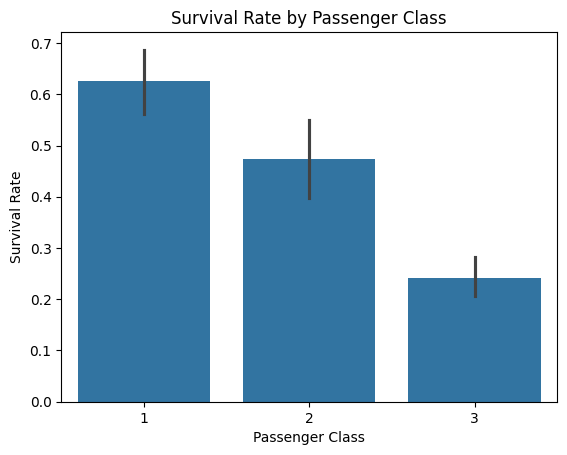

In [67]:
sns.barplot(
    data=missing_handled_df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()

Survival rate is also varying by passenger class. The death rate is much low in class 1 compared to class 3. Around 65% is the survival rate in class 1. For class 2, its about 45-50%. FOr class 3, its much lower, its around 25%.

#### (Plot 3) Bar Plot - Survival Rate by Sex and Passenger Class

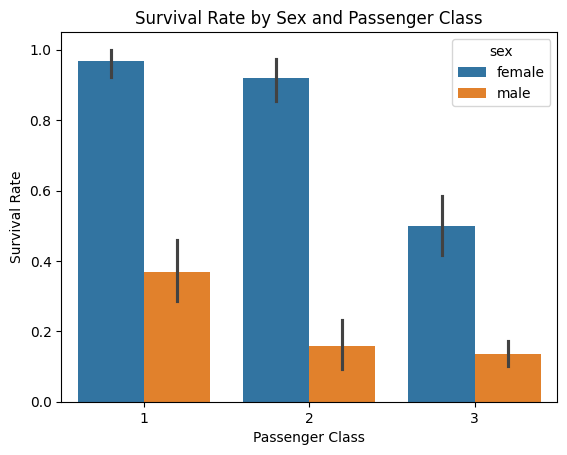

In [69]:
sns.barplot(
    data=missing_handled_df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()

It is evident from the chart that females of all classes are having a better survial rate than the males. While almost all the females of the passenger class 1, the survival rate of females is about 90-95% and 50-60% in class 3. Despite being low, the male survival rate is also class 1> class 2 > class 3. 

#### (Plot 4) Box plot - Age Distribution by Survival

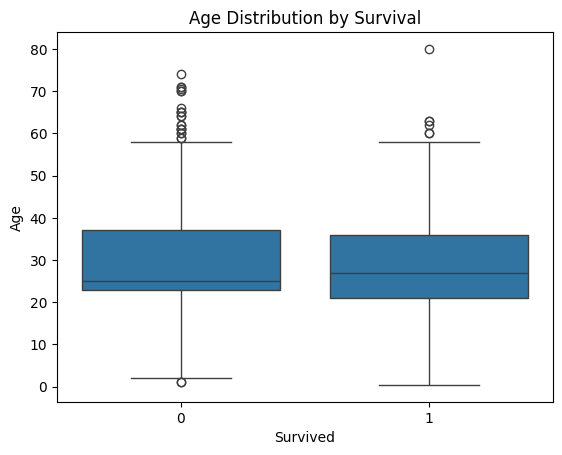

In [70]:
sns.boxplot(
    data=missing_handled_df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

The box plot shows that the median age of survivors (≈27 years) is slightly higher than that of non-survivors (≈25 years). The two age distributions have substantial overlap, with similar overall spreads. Therefore, age shows some association with survival, but it does not clearly distinguish survivors from non-survivors on its own.

## Exploratory Check

In [80]:
scaler = StandardScaler()

missing_handled_df[["age_zscore", "fare_zscore"]] = scaler.fit_transform(
    missing_handled_df[["age", "fare"]]
)

print("Attribute   | Before    | After")
print(
    f"Age         | {missing_handled_df['age'].mean():.2f}     | "
    f"{missing_handled_df['age_zscore'].mean():.2f}"
)
print(
    f"Fare        | {missing_handled_df['fare'].mean():.2f}     | "
    f"{missing_handled_df['fare_zscore'].mean():.2f}"
)



Attribute   | Before    | After
Age         | 29.02     | 0.00
Fare        | 32.10     | 0.00


The mean has reduced to 0 after using standard scaler